### For each cell type shared, perform the comparison between our DEG list using pseudobulked analysis vs. NEBULA mixed-effect approach

- Use lower fold change threshold of 0.1 for the NEBULA approach, since the fold changes even for significant genes is quite small
- But use fold change for pseudobulked approach

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def extract_significant_NEBULA(df, direction, logFC_threshold = 0.1, p_val_threshold = 0.05):
    '''Get either the significant up or down DEGs from a pydeseq2 directory''' 
    if direction == "up":
        sig_df = df[(df['p_adj_sexmale'] < p_val_threshold) & (df['logFC_sexmale'] > logFC_threshold)].copy()
        sig_df['direction']  = direction
    elif direction == "down":
        sig_df = df[(df['p_adj_sexmale'] < p_val_threshold) & (df['logFC_sexmale'] < -1 * logFC_threshold)].copy()
        sig_df['direction'] = direction
    else: 
        raise ValueError("direction must be 'up' or 'down'!")
    return sig_df

In [3]:
def extract_significant_pydeseq2(df, direction, logFC_threshold = 0.5, p_val_threshold = 0.05):
    '''Get either the significant up or down DEGs from a pydeseq2 directory''' 
    if direction == "up":
        sig_df = df[(df['log2FoldChange'] > logFC_threshold) & (df['padj'] < p_val_threshold)].copy()
        sig_df['direction']  = direction
    elif direction == "down":
        sig_df = df[(df['log2FoldChange'] < -logFC_threshold) & (df['padj'] < p_val_threshold)].copy()
        sig_df['direction']  = direction
    else: 
        raise ValueError("direction must be 'up' or 'down'!")
    return sig_df

In [4]:
def compare_DEGs(our_df, NEB_df, our_gene_col="gene_id", NEB_gene_col="gene", 
                direction_col="direction"):
    '''Compare DEGs between our dataset and Read et al.'''
    
    # generate sets
    our_up   = set(our_df.loc[our_df[direction_col]=="up",   our_gene_col])
    our_down = set(our_df.loc[our_df[direction_col]=="down", our_gene_col])
    
    NEB_up   = set(NEB_df.loc[NEB_df[direction_col]=="up",   NEB_gene_col])
    NEB_down = set(NEB_df.loc[NEB_df[direction_col]=="down", NEB_gene_col])
    
    results = {
        "shared_up":   len(our_up & NEB_up),
        "shared_down": len(our_down & NEB_down),
        "up_pseudo": len(our_up - NEB_up),
        "down_pseudo": len(our_down - NEB_down),
        "up_NEBULA": len(NEB_up - our_up),
        "down_NEBULA": len(NEB_down - our_down),
    }
    
    return results

### Test for one cell type

In [5]:
NEBULA_dir = "../../../NEBULA_analysis/NEBULA_results/"

In [6]:
NEBULA_DEG_df = pd.read_csv(NEBULA_dir + "Cardiomyocyte.csv", index_col = 0)
NEBULA_DEG_df

,logFC_(Intercept),logFC_sexmale,logFC_age_groupmiddle,logFC_age_groupold,logFC_tech_plus_study3prime-v2_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Chaffin 2022,logFC_tech_plus_study3prime-v3_Hill 2022,logFC_tech_plus_study3prime-v3_Kuppe 2022,logFC_tech_plus_study3prime-v3_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Reichart 2022,...,p_tech_plus_study3prime-v3_Reichart 2022,p_tech_plus_study3prime-v3_Simonson 2023,p_tech_plus_study5prime-v1_Koenig 2022,p_tech_plus_studyDropseq_Penn,p_tech_plus_studyMultiome-v1_ENCODE v4 (Snyder),p_tech_plus_studyMultiome-v1_Kanemaru 2023,gene_id,gene,p_adj_age_groupold,p_adj_sexmale
1,-14.530061,0.066682,-0.138607,-0.071521,1.486452,0.105827,1.056344,0.559947,0.992394,1.086054,...,8.521787e-06,1.122742e-01,9.838294e-01,2.107457e-01,0.334294,0.000656,2,LINC00115,1.000000e+00,1.000000
2,-11.081048,0.083093,0.050325,-0.001758,0.439968,0.089570,0.697795,0.254756,0.511966,0.633480,...,4.122747e-06,1.240812e-01,6.312957e-06,1.623901e-01,0.097876,0.131659,5,NOC2L,1.000000e+00,1.000000
3,-13.677883,0.043347,-0.021841,-0.205939,-0.562196,-0.893861,0.317171,0.297000,0.400572,0.341208,...,2.034950e-01,4.794541e-01,2.407663e-03,9.745629e-02,0.581961,0.150946,6,KLHL17,1.000000e+00,1.000000
4,-12.943395,0.010228,0.229187,0.177214,-1.881569,1.805808,0.351666,1.037167,0.643931,0.354084,...,2.604066e-01,3.247776e-12,4.975493e-10,9.892140e-01,0.000082,0.001995,7,PLEKHN1,1.000000e+00,1.000000
5,-10.890034,0.170627,-0.097929,-0.087122,0.444883,0.662959,2.138900,0.600201,2.170139,1.607047,...,5.579816e-04,5.941070e-01,5.734329e-01,1.485101e-01,0.000024,0.211056,8,HES4,1.000000e+00,0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12923,-12.301294,-0.191875,0.230267,0.281504,-3.039029,-4.205071,-0.253364,-1.884008,-4.321682,-2.223346,...,1.120421e-09,6.174872e-26,8.472806e-07,4.054360e-03,0.018940,0.011987,16111,MT-ND4L,1.000000e+00,1.000000
12924,-10.411454,-0.029678,0.461119,0.483199,-2.346658,-4.321616,-0.598295,-1.906866,-4.363663,-2.144141,...,3.052251e-08,1.245670e-37,9.432368e-03,1.054056e-08,0.252041,0.111572,16112,MT-ND4,3.517971e-14,1.000000
12925,-11.591058,-0.112275,0.017398,0.208266,-2.768985,-4.163103,-0.766296,-1.536789,-4.865461,-2.067358,...,6.102584e-11,1.549620e-35,9.442326e-02,2.094579e-04,0.413316,0.203486,16113,MT-ND5,1.000000e+00,1.000000
12926,-12.625606,-0.133176,0.172359,0.125626,-2.043817,-2.215978,-1.239546,-0.377680,-4.320384,-0.531247,...,1.560458e-01,7.521143e-12,2.059594e-02,9.837265e-01,0.595807,0.020599,16114,MT-ND6,1.000000e+00,1.000000


In [7]:
sig_NEBULA_DEG_df = extract_significant_NEBULA(NEBULA_DEG_df, direction = "down")
sig_NEBULA_DEG_df

,logFC_(Intercept),logFC_sexmale,logFC_age_groupmiddle,logFC_age_groupold,logFC_tech_plus_study3prime-v2_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Chaffin 2022,logFC_tech_plus_study3prime-v3_Hill 2022,logFC_tech_plus_study3prime-v3_Kuppe 2022,logFC_tech_plus_study3prime-v3_Litvinukova 2020,logFC_tech_plus_study3prime-v3_Reichart 2022,...,p_tech_plus_study3prime-v3_Simonson 2023,p_tech_plus_study5prime-v1_Koenig 2022,p_tech_plus_studyDropseq_Penn,p_tech_plus_studyMultiome-v1_ENCODE v4 (Snyder),p_tech_plus_studyMultiome-v1_Kanemaru 2023,gene_id,gene,p_adj_age_groupold,p_adj_sexmale,direction
109,-10.962066,-0.389108,-0.489690,-0.638705,-0.443757,-1.678907,-1.783107,-1.569497,-1.701650,-1.927986,...,6.269417e-03,7.715975e-01,0.160407,3.874095e-04,0.585924,138,NPPA,0.000182,1.038044e-05,down
448,-9.160309,-0.156049,-0.033424,-0.051529,-0.085756,-0.231040,-1.599656,-0.190381,-0.280973,-0.377706,...,2.018675e-01,3.876423e-01,0.142097,4.402949e-01,0.476334,564,AGBL4,1.000000,1.443561e-09,down
532,-11.485569,-0.178946,-0.045675,-0.112900,-1.704286,0.736554,1.086874,-1.288207,1.379129,1.025421,...,4.461267e-02,1.419301e-29,0.045154,2.682835e-02,0.004149,667,ZRANB2-AS1,1.000000,4.107477e-09,down
828,-10.952653,-0.204379,-0.047622,-0.064674,0.400924,-2.307309,-0.660556,0.537048,-0.742400,-0.486556,...,9.050326e-09,2.513364e-01,0.747101,2.779460e-04,0.011239,1019,RPS27,1.000000,3.390866e-02,down
933,-9.894617,-0.102998,-0.049849,-0.053509,-1.297593,-0.685680,-0.913258,-0.730825,-1.008197,-0.929643,...,1.020798e-05,1.759916e-09,0.006085,7.014221e-06,0.000603,1178,DDR2,1.000000,6.555315e-03,down
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12485,-10.538340,-0.101762,-0.118840,-0.136209,-0.335894,-0.084447,-0.181981,-0.279990,-0.102390,-0.252200,...,1.199333e-01,7.724652e-02,0.004048,2.072893e-20,0.099134,15561,CA5B,1.000000,1.832802e-02,down
12486,-11.069774,-0.127133,0.004325,0.019666,-0.184910,0.018832,-0.119581,0.054800,0.164722,-0.020211,...,2.903807e-02,8.021209e-01,0.218679,1.360521e-01,0.941367,15562,ZRSR2,1.000000,3.615621e-03,down
12609,-10.448999,-0.104531,0.026778,0.013181,-0.286608,0.025241,-0.051444,-0.037691,0.044429,-0.114890,...,2.179467e-01,3.179981e-02,0.048629,2.033157e-03,0.023275,15714,SMC1A,1.000000,4.661233e-04,down
12640,-10.891118,-0.207917,-0.152067,-0.173354,-0.466632,0.141104,-0.947614,0.104590,-0.313667,-0.554521,...,4.880475e-01,2.845350e-01,0.771500,8.885524e-02,0.950442,15748,ZC4H2,1.000000,9.204465e-05,down


In [8]:
our_DEG_df = pd.read_csv("../pydeseq2_results/Cardiomyocyte_sex_male_vs_female_results.csv", index_col = 0)
our_DEG_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,-log10(padj),significant
UTY,1862.234997,8.022860,0.202942,39.532797,0.000000,0.000000,UTY,300.000000,True
TSIX,719.755713,-8.819379,0.197666,-44.617492,0.000000,0.000000,TSIX,300.000000,True
XIST,4314.889409,-11.523447,0.166970,-69.015024,0.000000,0.000000,XIST,300.000000,True
EIF1AY,396.484216,8.682075,0.225236,38.546625,0.000000,0.000000,EIF1AY,300.000000,True
TTTY10,1353.756387,6.884495,0.170252,40.437104,0.000000,0.000000,TTTY10,300.000000,True
...,...,...,...,...,...,...,...,...,...
MBNL1-AS1,37.716708,-0.000042,0.116887,-0.000356,0.999716,0.999923,MBNL1-AS1,0.000034,False
NR2C2AP,19.317930,0.000106,0.148821,0.000716,0.999429,0.999923,NR2C2AP,0.000034,False
ZNF251,330.299647,0.000029,0.047775,0.000597,0.999524,0.999923,ZNF251,0.000034,False
KDM4C,1983.331283,0.000006,0.057427,0.000105,0.999916,0.999923,KDM4C,0.000034,False


In [9]:
sig_df = extract_significant_pydeseq2(our_DEG_df, direction="up")
sig_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,-log10(padj),significant,direction
UTY,1862.234997,8.022860,0.202942,39.532797,0.000000e+00,0.000000e+00,UTY,300.000000,True,up
EIF1AY,396.484216,8.682075,0.225236,38.546625,0.000000e+00,0.000000e+00,EIF1AY,300.000000,True,up
TTTY10,1353.756387,6.884495,0.170252,40.437104,0.000000e+00,0.000000e+00,TTTY10,300.000000,True,up
TTTY14,4272.289985,8.884928,0.238432,37.263971,6.293892e-304,1.690435e-300,TTTY14,299.570178,True,up
KDM5D,396.918918,8.554857,0.231944,36.883292,8.563210e-298,1.971373e-294,KDM5D,293.705231,True,up
...,...,...,...,...,...,...,...,...,...,...
SEMA3A,268.652833,0.539371,0.149998,3.595867,3.233128e-04,3.011668e-02,SEMA3A,1.521193,True,up
MCOLN2,19.780317,0.723438,0.202284,3.576344,3.484336e-04,3.172320e-02,MCOLN2,1.498623,True,up
PTPN13,40.756395,0.607278,0.171073,3.549814,3.855033e-04,3.451470e-02,PTPN13,1.461996,True,up
CMTM8,56.824305,0.529800,0.151640,3.493803,4.761917e-04,4.081824e-02,CMTM8,1.389146,True,up


### Iterate through all cell types

In [10]:
shared_cell_types = ['Adipocyte', 'Cardiomyocyte', 'Endocardial', 'Endothelial', 'Epicardial', 'Fibroblast',
                     'LEC', 'Lymphoid', 'Mast', 'Myeloid', 'Neuronal', 'Pericyte', 'vSMC']

In [11]:
results_list = list()

for cell_type in shared_cell_types:

    # extract significant DEGs in NEBULA approach
    NEBULA_DEG_df = pd.read_csv(NEBULA_dir + cell_type + ".csv", index_col = 0)
    NEB_sig_up_df = extract_significant_NEBULA(NEBULA_DEG_df, direction="up")
    NEB_sig_down_df = extract_significant_NEBULA(NEBULA_DEG_df, direction="down")
    NEB_concat_sig_df = pd.concat([NEB_sig_up_df, NEB_sig_down_df])

    # extract significant DEGs in pseudobulked approach
    our_DEG_df = pd.read_csv("../pydeseq2_results/" + cell_type + "_sex_male_vs_female_results.csv", index_col = 0)
    sig_up_df = extract_significant_pydeseq2(our_DEG_df, direction="up")
    sig_down_df = extract_significant_pydeseq2(our_DEG_df, direction="down")
    concat_sig_df = pd.concat([sig_up_df, sig_down_df])
    
    # compare up DEGs
    results = compare_DEGs(our_df=concat_sig_df, NEB_df=NEB_concat_sig_df)
    results['cell_type'] = cell_type

    # append both
    results_list.append(results)

results_df = pd.DataFrame(results_list)

In [12]:
results_df

,shared_up,shared_down,up_pseudo,down_pseudo,up_NEBULA,down_NEBULA,cell_type
0,2,1,11,4,0,1,Adipocyte
1,7,2,90,32,107,70,Cardiomyocyte
2,7,5,9,2,0,3,Endocardial
3,2,5,15,6,8,6,Endothelial
4,11,1,0,1,6,19,Epicardial
5,0,2,25,18,33,51,Fibroblast
6,11,1,1,5,0,0,LEC
7,8,9,6,7,1,5,Lymphoid
8,9,2,0,5,0,0,Mast
9,4,5,11,7,15,1,Myeloid


/mnt/data1/william/tmp/ipykernel_1131573/3760776429.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heatmap_colors = heatmap_df.applymap(lambda x: np.log1p(x))


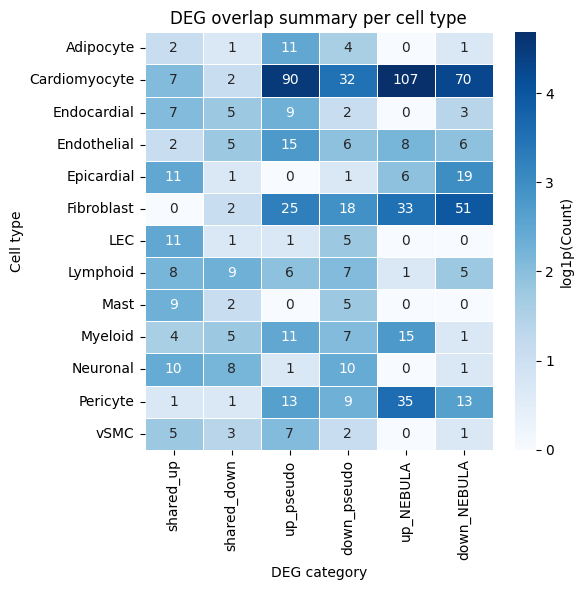

In [13]:
# Select metrics
heatmap_df = results_df.set_index("cell_type")[
    ["shared_up", "shared_down", "up_pseudo", "down_pseudo", "up_NEBULA", "down_NEBULA"]
]

custom_order = shared_cell_types

heatmap_df = heatmap_df.reindex(custom_order)

# Color values on log scale
heatmap_colors = heatmap_df.applymap(lambda x: np.log1p(x))

plt.figure(figsize=(6,6))
sns.heatmap(
    heatmap_colors,
    cmap="Blues",           
    annot=heatmap_df,      
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "log1p(Count)"}
)
plt.title("DEG overlap summary per cell type")
plt.ylabel("Cell type")
plt.xlabel("DEG category")
plt.tight_layout()

plt.savefig("Pseudobulk_vs_NEBULA_sex_DEGs.pdf")
plt.show()